# 04 - Inference Demo (MC Dropout)

**Purpose:** Simulate an online engine health monitor with uncertainty-aware RUL output.

**Inputs:** `model/best_model.pth`, `data/processed/test_engine_trajectories.pkl`

**Outputs:** predicted RUL curve with 95% uncertainty band and final-step summary.

In [2]:
import pickle
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
import torch

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "processed").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from model.lstm_model import LSTMRULModel, mc_dropout_predict

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_PATH = PROJECT_ROOT / "model" / "best_model.pth"
DEVICE = torch.device("cpu")
RUL_CAP = 125.0

In [3]:
with open(PROCESSED_DIR / "test_engine_trajectories.pkl", "rb") as fp:
    test_trajectories = pickle.load(fp)

engine_ids = sorted(test_trajectories.keys())
engine_id = engine_ids[len(engine_ids) // 2]
payload = test_trajectories[engine_id]

model = LSTMRULModel(input_size=14, hidden_size=128, num_layers=2, dropout=0.2).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))

sequences = torch.tensor(payload["sequences"], dtype=torch.float32, device=DEVICE)
cycles = np.array(payload["cycles"])
actual_rul = np.array(payload["actual_rul"])

mean_rul, std_rul = mc_dropout_predict(model, sequences, n_passes=50)
mean_rul = mean_rul.numpy() * RUL_CAP
std_rul = std_rul.numpy() * RUL_CAP

lower = mean_rul - 1.96 * std_rul
upper = mean_rul + 1.96 * std_rul

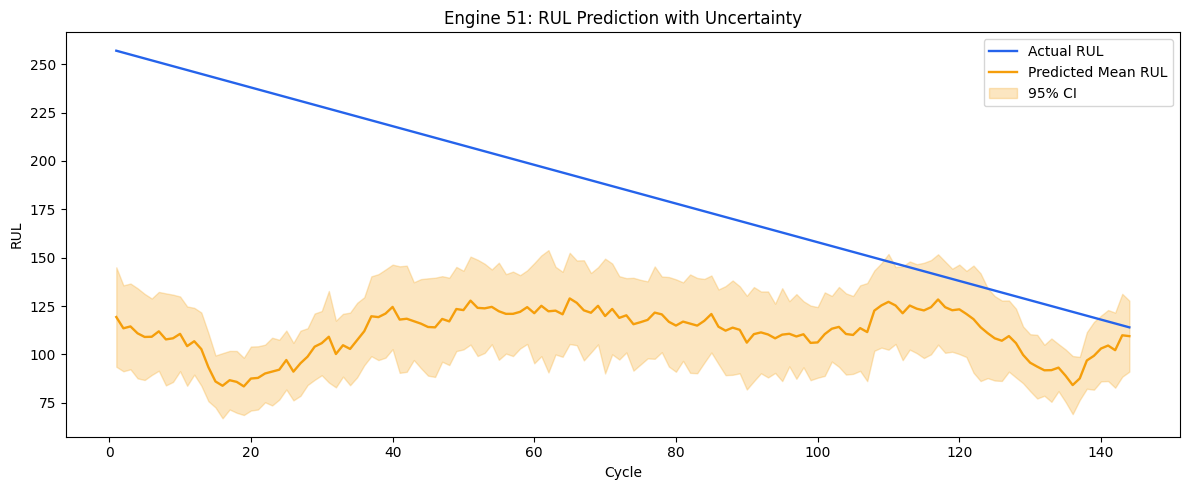

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(cycles, actual_rul, label="Actual RUL", color="#2563eb", linewidth=1.7)
plt.plot(cycles, mean_rul, label="Predicted Mean RUL", color="#f59e0b", linewidth=1.7)
plt.fill_between(cycles, lower, upper, color="#f59e0b", alpha=0.25, label="95% CI")
plt.title(f"Engine {engine_id}: RUL Prediction with Uncertainty")
plt.xlabel("Cycle")
plt.ylabel("RUL")
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
final_mean = float(mean_rul[-1])
final_std = float(std_rul[-1])
final_ci = (final_mean - 1.96 * final_std, final_mean + 1.96 * final_std)

print(f"Engine ID: {engine_id}")
print(f"Final predicted RUL: {final_mean:.2f}")
print(f"Final uncertainty (std): {final_std:.2f}")
print(f"Final 95% CI: [{final_ci[0]:.2f}, {final_ci[1]:.2f}]")

Engine ID: 51
Final predicted RUL: 109.45
Final uncertainty (std): 9.36
Final 95% CI: [91.10, 127.81]
